In [1]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

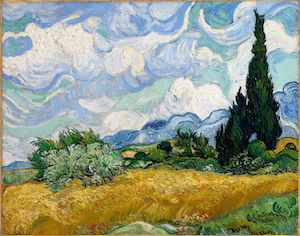

In [2]:
display(REFERENCE_IMAGE)

In [3]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = False

In [4]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.mutation_strength_schedule}_{evo.initial_mutation_strength}_{evo.final_mutation_strength}_{evo.mutation_prob_schedule}_{evo.initial_mutation_prob}_{evo.final_mutation_prob}_{time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob = settings
    start = time()
    
    data = []
    evo = Evolution(100,
                    REFERENCE_IMAGE,
                    population_size=100,
                    generation_reporter=reporter,
                    crossover_method="ONE_POINT",
                    seed=seed,
                    initialization="RANDOM",
                    generation_budget=500,
                    
                    mutation_strength_schedule=mutation_strength_schedule,
                    initial_mutation_strength=initial_strength,
                    final_mutation_strength=final_strength,
                    
                    mutation_prob_schedule=mutation_prob_schedule,
                    initial_mutation_prob=initial_prob,
                    final_mutation_prob=final_prob,
                    
                    selection_name='tournament_4',
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: seed {seed} - strength {mutation_strength_schedule} {initial_strength} -> {final_strength} - prob {mutation_prob_schedule} {initial_prob} -> {final_prob} - in {int(time_spent)} seconds")
    
    return data

## Running a single instance

In [5]:
%%time
data = run_algorithm((0, "constant", 0.5, 0.05, "constant", 0.1, 0.01))

Done: seed 0 - strength constant 0.5 -> 0.05 - prob constant 0.1 -> 0.01 - in 141 seconds
CPU times: user 1min 19s, sys: 10.8 s, total: 1min 29s
Wall time: 2min 21s


## Running a sweep of settings

In [7]:
%%time

#one trial = 150 seconds = 2.5 minutes
n_trials = 20

data = []
for seed in range(n_trials):
    for _ in range(1):

        mutation_strength_schedule = np.random.choice(["constant", "linear", "exponential", "quadratic"])
        initial_strength = np.random.uniform(0.1, 1.0)
        if mutation_strength_schedule == "constant":
            final_strength = initial_strength
        else:
            final_strength = np.random.uniform(0.001, initial_strength)

        mutation_prob_schedule = np.random.choice(["constant", "linear", "exponential", "quadratic"])
        initial_prob = np.random.uniform(0.001, 0.1)
        if mutation_prob_schedule == "constant":
            final_prob = initial_prob
        else:
            final_prob = np.random.uniform(0.0001, initial_prob)

        data.extend(run_algorithm((seed, mutation_strength_schedule, initial_strength, final_strength, mutation_prob_schedule, initial_prob, final_prob)))

Done: seed 0 - strength exponential 0.500704030114764 -> 0.100959700970734 - prob exponential 0.07393114050724013 -> 0.011421013328237754 - in 143 seconds
Done: seed 1 - strength constant 0.7615041552090552 -> 0.7615041552090552 - prob quadratic 0.03259065306175116 -> 0.021335927915717475 - in 142 seconds
Done: seed 2 - strength constant 0.632830487521154 -> 0.632830487521154 - prob exponential 0.09860226547626262 -> 0.0861474478683676 - in 142 seconds
Done: seed 3 - strength linear 0.8465529152300039 -> 0.7256504844340035 - prob linear 0.02054416936217368 -> 0.012777997139098553 - in 142 seconds
Done: seed 4 - strength exponential 0.37253041036348666 -> 0.34601873185491827 - prob quadratic 0.0542056894266793 -> 0.012352226442303696 - in 141 seconds
Done: seed 5 - strength quadratic 0.2290671723143656 -> 0.16081153087599273 - prob quadratic 0.016912059341676246 -> 0.012233462516928178 - in 140 seconds
Done: seed 6 - strength constant 0.7616698867635672 -> 0.7616698867635672 - prob expo

## Evaluating the results

In [8]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

In [9]:
# your plotting code here...

In [10]:
df.head()

,num-generations,num-evaluations,time-elapsed,best-fitness,avg-fitness,crossover-method,population-size,num-points,initialization,mutation-strength-schedule,initial-mutation-strength,final-mutation-strength,mutation-prob-schedule,initial-mutation-prob,final-mutation-prob,seed
0,1,200,0.0,136389,144036.78,ONE_POINT,100,100,RANDOM,exponential,0.500704,0.10096,exponential,0.073931,0.011421,0
1,2,300,0.0,133381,140129.36,ONE_POINT,100,100,RANDOM,exponential,0.500704,0.10096,exponential,0.073931,0.011421,0
2,3,400,1.0,130372,136609.36,ONE_POINT,100,100,RANDOM,exponential,0.500704,0.10096,exponential,0.073931,0.011421,0
3,4,500,1.0,126307,134049.06,ONE_POINT,100,100,RANDOM,exponential,0.500704,0.10096,exponential,0.073931,0.011421,0
4,5,600,1.0,126307,131587.60,ONE_POINT,100,100,RANDOM,exponential,0.500704,0.10096,exponential,0.073931,0.011421,0


In [23]:
summary = df.groupby([
    "mutation-strength-schedule",
    "initial-mutation-strength",
    "final-mutation-strength",
    "mutation-prob-schedule",
    "initial-mutation-prob",
    "final-mutation-prob"
])["best-fitness"].min().reset_index()

summary.sort_values("best-fitness").head(20)

,mutation-strength-schedule,initial-mutation-strength,final-mutation-strength,mutation-prob-schedule,initial-mutation-prob,final-mutation-prob,best-fitness
9,exponential,0.838521,0.167024,quadratic,0.022027,0.004760,39886
3,constant,0.761670,0.761670,exponential,0.009966,0.004549,42239
0,constant,0.588642,0.588642,quadratic,0.062516,0.000575,42274
16,quadratic,0.229067,0.160812,quadratic,0.016912,0.012233,48134
14,linear,0.846553,0.725650,linear,0.020544,0.012778,50620
5,exponential,0.372530,0.346019,quadratic,0.054206,0.012352,51266
7,exponential,0.500704,0.100960,exponential,0.073931,0.011421,52188
6,exponential,0.452217,0.275017,quadratic,0.035084,0.018982,53142
4,exponential,0.329617,0.068949,exponential,0.046696,0.009046,54381
8,exponential,0.730637,0.675413,linear,0.059603,0.014013,59594


In [18]:
configs = (df[["mutation-strength-schedule",
    "initial-mutation-strength",
    "final-mutation-strength",
    "mutation-prob-schedule",
    "initial-mutation-prob",
    "final-mutation-prob"]].drop_duplicates().values.tolist())

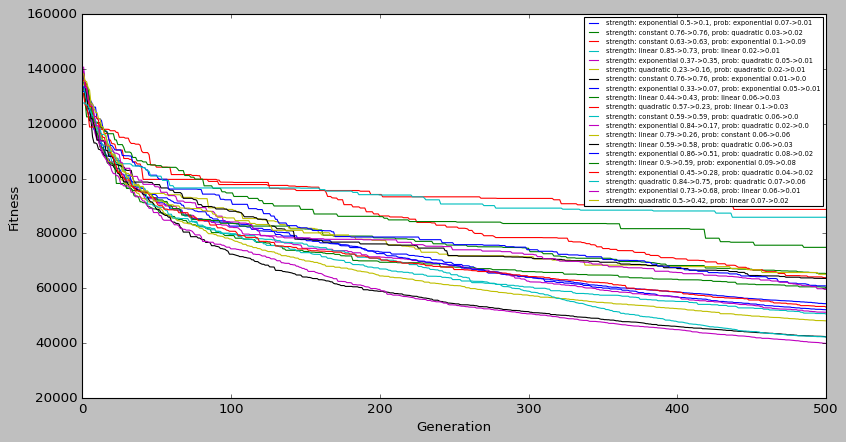

In [19]:
fig, ax = plt.subplots(figsize=(12,6))

for (schedule_s, init_s, final_s, schedule_p, init_p, final_p) in configs:

    sub = df[
        (df["mutation-strength-schedule"] == schedule_s) &
        (df["initial-mutation-strength"] == init_s) &
        (df["final-mutation-strength"] == final_s) &
        (df["mutation-prob-schedule"] == schedule_p) &
        (df["initial-mutation-prob"] == init_p) &
        (df["final-mutation-prob"] == final_p)
    ]

    mean_curve = sub.groupby("num-generations")["best-fitness"].mean()

    ax.plot(mean_curve.index, mean_curve.values,
            label=f"strength: {schedule_s} {round(init_s,2)}->{round(final_s,2)}, prob: {schedule_p} {round(init_p,2)}->{round(final_p,2)}")

ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.legend(fontsize=6)
plt.show()

## Displaying the best instances over time

In [20]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, mutation_strength_schedule, initial_mutation_strength, final_mutation_strength, mutation_prob_schedule, initial_mutation_prob, final_mutation_prob = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, 500 + 50, 50)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{mutation_strength_schedule}_{initial_mutation_strength}_{final_mutation_strength}_{mutation_prob_schedule}_{initial_mutation_prob}_{final_mutation_prob}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

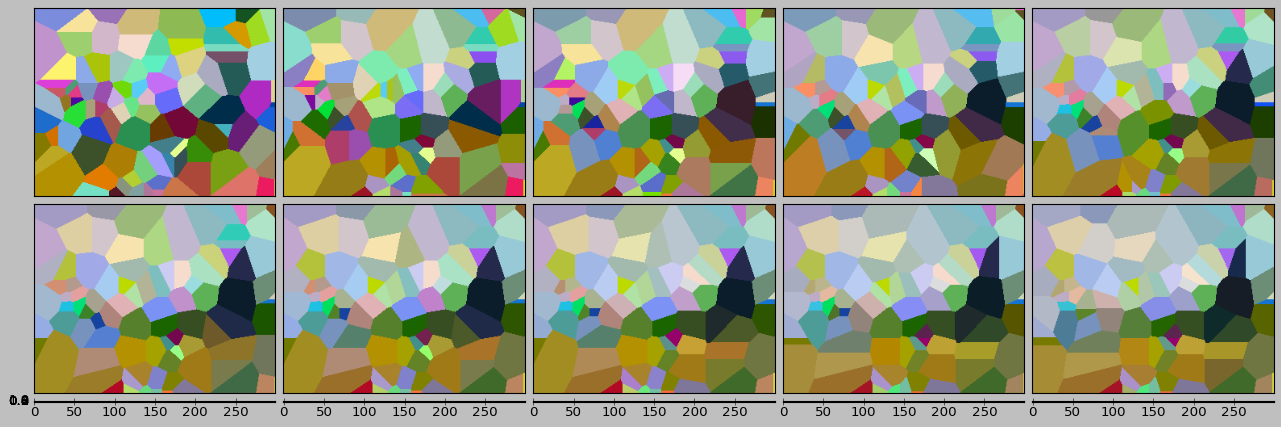

In [22]:
show_progress_over_time((11, "exponential", 0.8385208084518004, 0.16702410663196682, "quadratic", 0.022026889230164097, 0.004759818397991004), grid=(3,5))